# Instructor Effectiveness Modeling (EdTech)

This notebook analyzes instructor performance using learner outcomes, engagement, and feedback metrics.

Goals:
1. Explore the dataset (EDA)
2. Define an Instructor Effectiveness Score
3. Aggregate batch data to instructor level
4. Build a ML model to predict effectiveness tiers
5. Evaluate the model
6. Interpret the Results

Libraries Used:
- pandas
- numpy
- scikit-learn
- matplotlib
- seaborn

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

## Load DataSet

In [5]:
# read dataset
df = pd.read_csv("instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [6]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [9]:
#check missing value 
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

## 1. Exploratory Data Analysis (EDA)

In this section, I explore the dataset to understand the distribution of different variables and the relationships between them.

EDA helps us:
- Understand how the data is structured
- Identify patterns and relationships between variables
- Detect outliers or unusual values
- Gain early insights before building a machine learning model

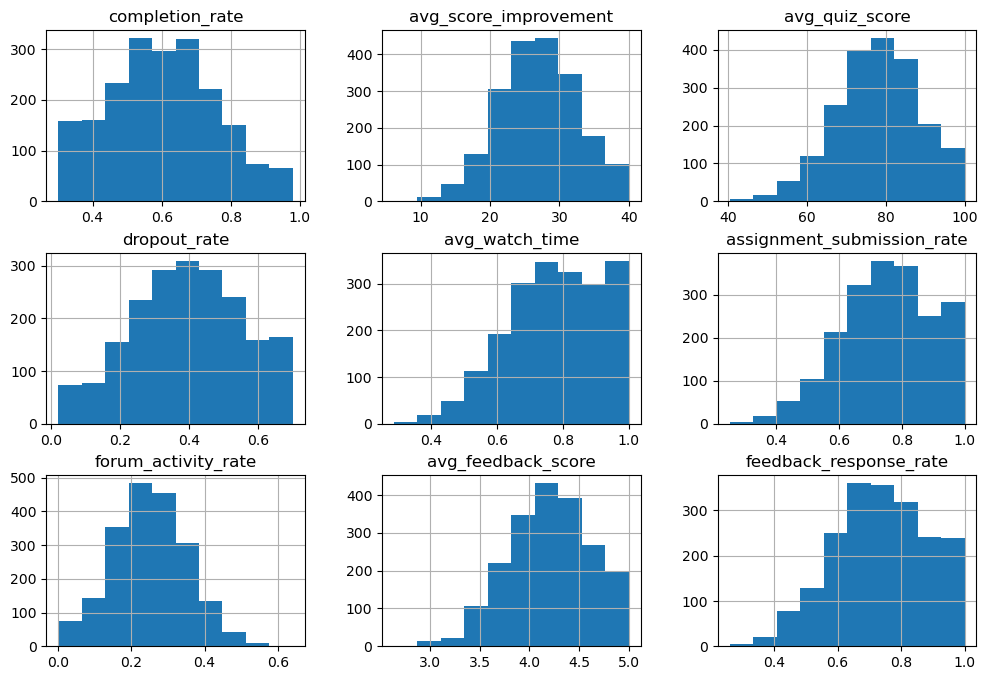

In [14]:
df.hist(figsize=(12,8))
plt.show()

## Feature Correlation Analysis
1. The heatmap shows the correlation between different variables. 
2. This helps identify relationships between learner outcomes, engagement metrics, and feedback scores.

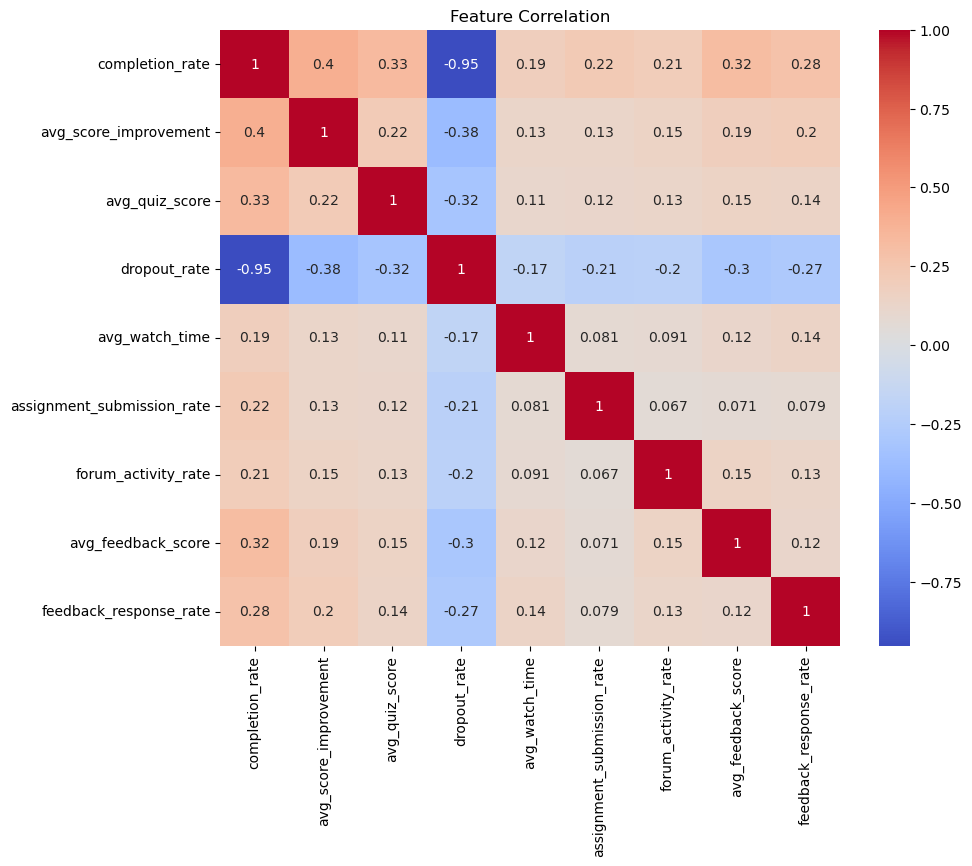

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

## Quiz Score Distribution and Outlier Detection
This boxplot visualizes the distribution of average quiz scores across batches 
and helps identify potential outliers or unusual values.

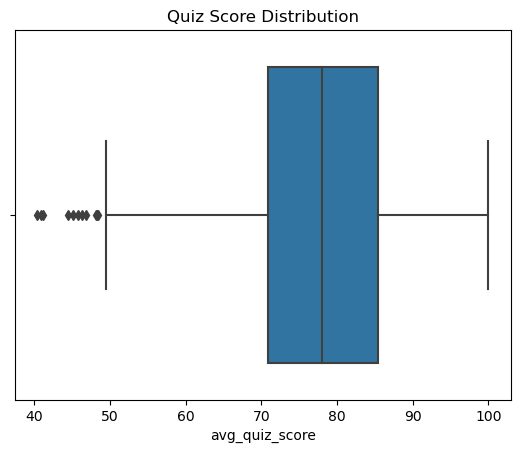

In [16]:
sns.boxplot(x=df['avg_quiz_score'])
plt.title("Quiz Score Distribution")
plt.show()

## Feedback Score Distribution
1. This histogram shows how learner feedback scores are distributed. 
2. Higher feedback scores may indicate better instructor performance.

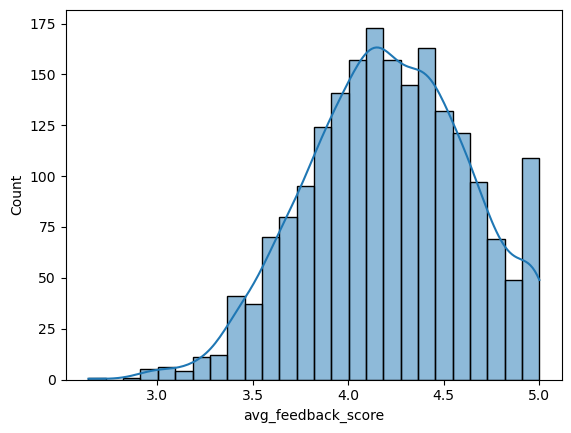

In [18]:
sns.histplot(df['avg_feedback_score'], kde=True)
plt.show()

## Completion Rate Distribution
This histogram illustrates how completion rates vary across different course batches.

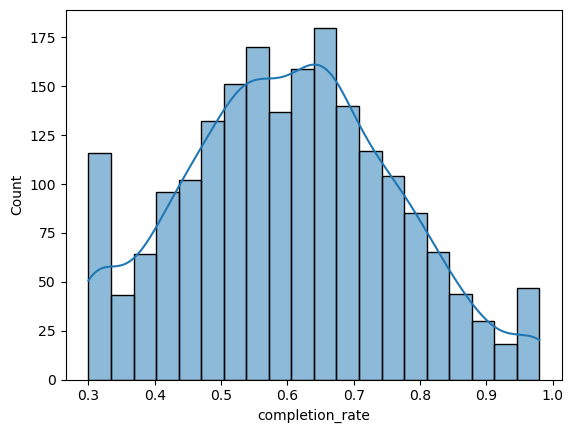

In [19]:
sns.histplot(df['completion_rate'], kde=True)
plt.show()

## Key Insights from Exploratory Data Analysis

From the exploratory data analysis, we can observe several important patterns in the dataset.

1. Completion rate and dropout rate show an inverse relationship. Batches with higher completion rates tend to have lower dropout rates.

2. Engagement metrics such as average watch time and assignment submission rate appear to be positively related to learner outcomes. This suggests that when learners engage more with the course content, their performance improves.

3. The distribution of quiz scores shows that most batches have moderate to high scores, but a few outliers exist.

4. Feedback scores are generally high, indicating that learners are mostly satisfied with the courses and instructors.

5. These variables together suggest that learner engagement, course completion, and feedback are likely important indicators of instructor effectiveness.

## 2. Define Instructor Effectiveness Score

In [20]:
df["effectiveness_score"] = (
    0.25 * df["completion_rate"] +
    0.20 * df["avg_score_improvement"] +
    0.15 * df["avg_quiz_score"]/100 +
    0.15 * df["avg_watch_time"] +
    0.10 * df["assignment_submission_rate"] +
    0.10 * (df["avg_feedback_score"]/5) -
    0.05 * df["dropout_rate"])

## Defining Instructor Effectiveness

Instructor effectiveness refers to how well an instructor helps learners successfully complete the course, improve their knowledge, stay engaged with the content, and feel satisfied with the learning experience.

To measure instructor effectiveness, I combine three major aspects of the learning process:

1. Learner Outcomes  
   Metrics such as completion rate, quiz score, and score improvement show whether learners are actually learning and completing the course.

2. Learner Engagement  
   Engagement metrics such as watch time, assignment submission rate, and forum activity show how actively learners participate in the course.

3. Learner Feedback  
   Feedback score reflects learner satisfaction with the instructor and the course experience.

Dropout rate is also considered because a high dropout rate may indicate lower instructor effectiveness.
Using these factors, I create an Instructor Effectiveness Score that combines these metrics into a single value.

In [23]:
#Convert Score into Effectiveness Tier
df["effectiveness_tier"] = pd.qcut(
    df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

#check distribution
df["effectiveness_tier"].value_counts()

Low       667
High      667
Medium    666
Name: effectiveness_tier, dtype: int64

## 3. Aggregate batch data to instructor level

Each row in the dataset represents a course batch, but instructors may teach multiple batches. 
To evaluate instructor effectiveness, we need to combine batch-level data into instructor-level data.
Therefore, I aggregate the batch metrics for each instructor.

### Aggregation Strategy
For most numerical features, I use the **mean (average)** value across batches. 
The mean helps capture the typical performance of an instructor across all the batches they have taught.

### Handling Instructors with Different Numbers of Batches
Instructors may have different numbers of batches:

- **Few batches:** Their average performance may be less stable because it is based on limited data.
- **Many batches:** Their aggregated metrics are more reliable because they are calculated from more observations.

To partially address this issue, I also compute the **number of batches per instructor** so that we can understand how much data contributes to each instructor's score.

In [26]:
instructor_df = df.groupby("instructor_id").agg({
    "completion_rate":"mean",
    "dropout_rate":"mean",
    "avg_score_improvement":"mean",
    "avg_quiz_score":"mean",
    "avg_watch_time":"mean",
    "assignment_submission_rate":"mean",
    "forum_activity_rate":"mean",
    "avg_feedback_score":"mean",
    "feedback_response_rate":"mean",
    "effectiveness_score":"mean",
    "batch_id":"count"
}).reset_index()

instructor_df.rename(columns={"batch_id":"num_batches"}, inplace=True)
instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,num_batches
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,5.831106,25
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,6.616121,20
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,6.588047,18
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,5.062473,17
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,7.152921,19


### Why These Aggregation Functions Make Sense

1. **Mean (Average)**  
   The mean is used because it represents the overall performance of an instructor across all batches they have taught.

2. **Batch Count**  
   The number of batches is included to understand how much data contributes to an instructor's aggregated metrics. 
   Instructors with more batches provide more reliable performance estimates.

3. **Consistency Across Features**  
   Using the same aggregation method (mean) for most features keeps the interpretation simple and consistent.

## 4. Build a ML model to predict effectiveness tiers

### Building a Machine Learning Model

In this step, we build a machine learning model to predict the **Instructor Effectiveness Tier** (Low, Medium, High).
The goal is to learn patterns from instructor-level features such as learner outcomes, engagement metrics, and feedback scores.

### Model Choice
We use **Random Forest Classifier** because:
- It works well with tabular datasets
- It can capture non-linear relationships between variables
- It provides feature importance which helps interpret results

Before training the model, we split the data into training and testing sets.

In [28]:
from sklearn.model_selection import train_test_split

# target variable
instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

X = instructor_df.drop(["instructor_id","effectiveness_tier"], axis=1)
y = instructor_df["effectiveness_tier"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Feature Scaling
Feature scaling is applied to ensure that all variables are on a similar scale.  

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
#Train Model
from sklearn.ensemble import RandomForestClassifier 
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Evalute the Model

To evaluate the model, we use the following metrics:
1. **Accuracy** – measures overall correct predictions
2. **Precision** – how many predicted instructors in a tier are actually correct
3. **Recall** – how many actual instructors in a tier are correctly identified
4. **F1 Score** – balance between precision and recall

These metrics help us understand how well the model performs across different effectiveness tiers.

In [32]:
#Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         9
         Low       1.00      1.00      1.00         8
      Medium       1.00      1.00      1.00         7

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



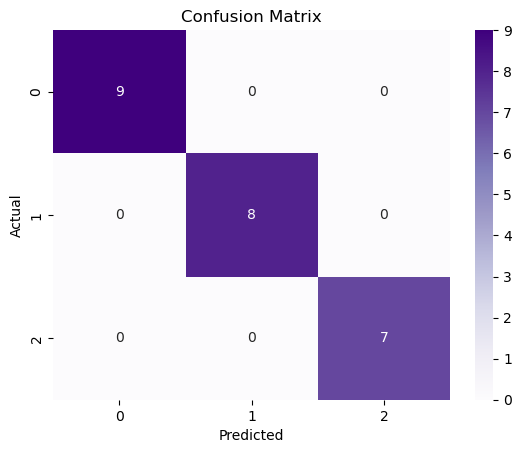

In [35]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Precision vs Recall Trade-off
Precision focuses on the correctness of predicted classes, while recall focuses on capturing all actual instances of a class.
In the context of instructor effectiveness:
- High **precision** ensures that instructors classified as high-performing are truly effective.
- High **recall** ensures that most effective instructors are correctly identified.

Balancing these metrics is important to avoid misclassification.

### Class Imbalance

If the dataset has significantly more instructors in one tier than others, the model may become biased toward predicting the majority class.In such cases, techniques like resampling or class weighting could be used to balance the dataset.

## Interpret the Results

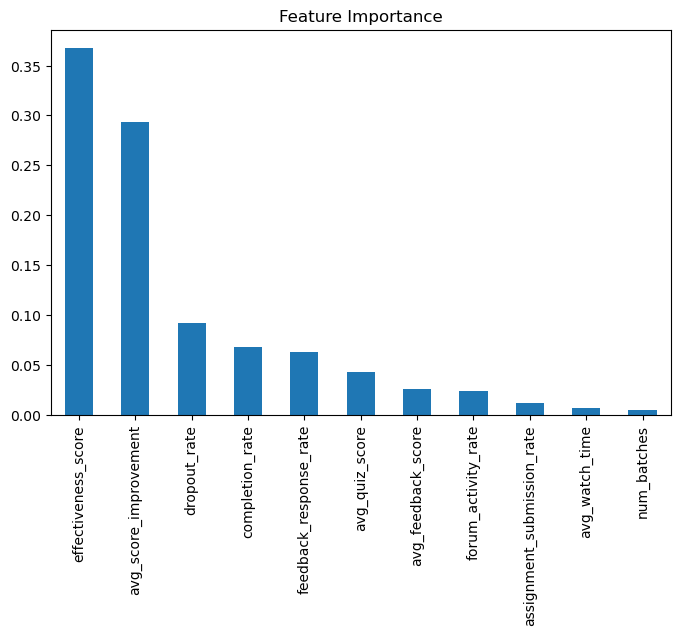

In [36]:
## Interpreting Model Results
import pandas as pd
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind="bar", figsize=(8,5))
plt.title("Feature Importance")
plt.show()

### Key Features Influencing Instructor Effectiveness

Based on the model results, some features play a stronger role in predicting instructor effectiveness:
- **Completion Rate** – Higher completion suggests better teaching effectiveness.
- **Average Score Improvement** – Indicates how much learners improved during the course.
- **Average Feedback Score** – Reflects learner satisfaction with the instructor.
- **Assignment Submission Rate** – Shows how engaged learners are in course activities.

# Practical Use in an EdTech Product
### Application in an EdTech Platform

This model could help EdTech companies:
1. Identify high-performing instructors.
2. Detect instructors who may need additional support or training.
3. Improve course quality by analyzing engagement and learning outcomes.

However, this model should not be used as the only measure of instructor performance.  
Human evaluation and qualitative feedback should also be considered.

## Mandatory Questions (1 to 5)

## 1. Which features most influenced instructor effectiveness, and why?
Based on the model results and feature importance, the most influential features were:

• Completion Rate – A higher completion rate shows that more students successfully finished the course. This often indicates effective teaching.

• Average Score Improvement – This measures how much learners improved from the beginning to the end of the course. It reflects the learning impact of the instructor.

• Average Feedback Score – Feedback represents learner satisfaction with the instructor and course experience.

• Assignment Submission Rate – When more learners submit assignments, it suggests higher engagement with the course content.

These features directly reflect learner success, engagement, and satisfaction, which are key indicators of instructor effectiveness.

## 2. Which variables could be misleading or confounded?
Some variables in the dataset may not fully reflect instructor performance.

• Forum Activity Rate – High activity in forums may depend on course difficulty or student behavior rather than instructor quality.

• Average Quiz Score – Quiz scores can vary depending on quiz difficulty, not only teaching effectiveness.

• Feedback Score – Learner feedback can sometimes be biased. Students may give higher ratings to easier courses.

## 3. How could this model fail in real-world usage?
This model may face several challenges in real-world situations.

• New instructors with very few batches may not have enough data for reliable predictions.

• Course difficulty may vary across courses, which can affect completion rates and scores.

• Different student backgrounds or skill levels may influence outcomes.

Because of these factors, the model predictions may not always fully represent instructor effectiveness.

## 4. What additional data would you want to improve this analysis?
To improve the analysis, the following additional data would be helpful:

•  Instructor experience or years of teaching

•  Course difficulty level

•  Number of students in each batch

•  Live session participation

•  Student demographics or prior knowledge

These additional features could help create a more accurate and fair model.

## 5. Should this model be used for instructor performance evaluation? Why or why not?

This model should not be used as the only method to evaluate instructor performance.While it provides useful insights based on learner outcomes, engagement, and feedback, it may not capture all aspects of teaching quality.
Other factors such as course difficulty, student background, and instructor teaching style should also be considered.
Therefore, this model should be used as a supporting tool rather than the sole evaluation method.